# Notebook 4 — The Natural Selection of Bad Science (NSOBS)
**Modeling Social Behavior** | Smaldino

--- 

This is the **capstone** of Chapter 8.  
All previous notebooks asked: "What does bad science *produce*?"  
This notebook asks: "Why does bad science *persist and spread*?"

The answer is evolution. Scientific practices that maximize publication output —  
not scientific accuracy — are selectively favored when labs compete for reproduction.

**Reference:** Smaldino & McElreath (2016). *The natural selection of bad science.*  
Royal Society Open Science 3: 160384.

---

## 🧠 Conceptual Overview

### What kind of model is this?

This is a full **agent-based model (ABM)**. Each agent is a **research lab** with heritable traits.  
Labs produce publications, and successful labs are copied — with mutation — into new labs.  
Less successful labs eventually die off. This is **cultural evolution** of scientific practice.

### What are the heritable traits?

Each lab has two evolutionarily variable traits:

1. **Power (β)** — how carefully the lab designs studies to detect true effects  
   - High power = expensive (requires large samples, careful measurement)  
   - Increases true positive rate  
   - Is under *positive* selection from the standpoint of accuracy  
   - But each study takes more effort...

2. **Effort (e)** — how much time/resources a lab spends per study  
   - High effort = fewer studies per time unit (throughput decreases)  
   - Reduces false positive rate (via its mechanistic link in the model)  
   - The false positive rate is computed FROM effort: `fpr = power / (1 + (1 - power) × effort)`

### The core tradeoff

A lab can do **one rigorous study** or **many sloppy studies** in the same time.  
The incentive structure rewards *publications*, not *accuracy*.  
Sloppy labs publish more (more throughput, lower quality threshold per paper).  
Rigorous labs publish fewer but better papers.

Under natural selection pressure (labs replicate based on publication count),  
the **sloppy strategy out-competes the rigorous one** — not because anyone intends it,  
but because the incentive structure selects for quantity over quality.

### The evolutionary algorithm

Each tick:
1. **Science step:** Every lab tries `new_hypothesis` → runs a study → possibly publishes
2. **Evolution step:**
   - Sample `reproduction_samplesize` labs → **kill the oldest** (death)
   - Sample `reproduction_samplesize` labs → **clone the most-published** (birth)
   - The clone inherits power and effort, but both can **mutate** (with SD and rate parameters)
3. Track mean power, mean fpr, and the false discovery rate over time

### Key outputs

- **Mean power (β):** Does it go up (good) or down (bad)?
- **Mean false positive rate (fpr):** Does it go up (bad) or down (good)?
- **False discovery rate (FDR):** What fraction of published results are wrong?
- **Mean effort (e):** Does rigor increase or decrease over evolutionary time?

### The central finding

Under most realistic parameter settings, **mean power decreases and mean false positive rate increases** over evolutionary time — the scientific community evolves toward bad science — **because publication pressure selects for quantity over quality**.

Introducing rewards for negative results (`payoff_neg_result > 0`) can partially reverse this.


## Setup — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import List
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Agent Definition — The Lab

In the NetLogo model, each "turtle" is a research lab.  
We represent each lab as a Python dataclass with its own state (agent-level variables).

### Variable types

**Agent-level variables** (each lab has its own copy):
- `power` — statistical power β ∈ [0, 1]
- `effort` — effort per study e ∈ [1, 100]
- `false_pos_rate` — derived from power and effort: `fpr = power / (1 + (1-power)×effort)`
- `pub_payoff` — cumulative publication count (used for selection)
- `age` — how many ticks this lab has existed (used for death selection)

**Global variables** (shared across the simulation):
- `effort_influence` — scaling constant (0.2) in the new-hypothesis probability function
- `reproduction_samplesize` — how many labs are sampled for death/birth tournaments


In [2]:
@dataclass
class Lab:
    """
    A research lab agent.
    
    All attributes are AGENT-LEVEL variables — each lab has its own copy.
    """
    power:         float   # β — probability of detecting a true effect (heritable)
    effort:        float   # e — effort per study, controls throughput (heritable)
    false_pos_rate: float  # α — false positive rate, DERIVED from power and effort
    pub_payoff:    float = 0.0   # cumulative publication score (reset on reproduction)
    age:           int   = 0     # ticks alive (used for death selection)
    
    def compute_fpr(self):
        """
        Recompute false positive rate from power and effort.
        
        Formula: fpr = power / (1 + (1 - power) × effort)
        
        Intuition: 
        - Higher effort → more careful design → lower false positive rate
        - Higher power → better sensitivity, but also slightly higher fpr
          (the formula captures a realistic tradeoff between sensitivity and specificity)
        """
        self.false_pos_rate = self.power / (1 + (1 - self.power) * self.effort)
    
    def prob_new_hypothesis(self, effort_influence: float) -> float:
        """
        Probability that this lab attempts a NEW study this tick.
        
        Formula: 1 - effort_influence × log10(effort)
        
        HIGH effort → high log10(effort) → LOWER probability of new study
        This captures the throughput cost of rigor: careful labs publish less frequently.
        
        Parameters
        ----------
        effort_influence : float — GLOBAL scaling constant (0.2)
        
        Returns
        -------
        float in [0, 1] — probability of running a new study this tick
        """
        prob = 1.0 - effort_influence * np.log10(self.effort)
        return max(0.0, min(1.0, prob))   # clamp to [0,1]
    
    def mutate(self, mutation_rate_power, mutation_sd_power,
               mutation_rate_effort, mutation_sd_effort):
        """
        Apply random mutation to power and effort.
        
        Each trait mutates with a given probability; mutation size is drawn from N(0, SD).
        Traits are clamped to valid ranges after mutation.
        
        This is an AGENT-LEVEL procedure (each newborn lab calls it on itself).
        """
        # Mutate power
        if np.random.random() < mutation_rate_power:
            self.power += np.random.normal(0, mutation_sd_power)
            self.power = max(0.0, min(1.0, self.power))   # power ∈ [0, 1]
        
        # Mutate effort
        if np.random.random() < mutation_rate_effort:
            self.effort += np.random.normal(0, mutation_sd_effort)
            self.effort = max(1.0, min(100.0, self.effort))   # effort ∈ [1, 100]

print("Lab class defined.")

# Quick sanity check
test_lab = Lab(power=0.8, effort=75, false_pos_rate=0.0)
test_lab.compute_fpr()
print(f"Lab with power=0.8, effort=75 → fpr = {test_lab.false_pos_rate:.4f}")
print(f"Prob of new hypothesis = {test_lab.prob_new_hypothesis(0.2):.4f}")


Lab class defined.
Lab with power=0.8, effort=75 → fpr = 0.0500
Prob of new hypothesis = 0.6250


## Global Parameters

These are the sliders in the NetLogo model.


In [3]:
# ── GLOBAL VARIABLES ──────────────────────────────────────────────────────

# --- Population parameters ---
num_labs   = 100       # N: number of research labs in the community

# --- Study parameters ---
base_rate  = 0.1       # b: proportion of tested hypotheses that are actually true
                        # Low base rate = most hypotheses are false (common in exploratory science)

# --- Initial trait values (set at lab creation) ---
effort_init = 75.0     # e_0: starting effort per study
power_init  = 0.8      # W_0: starting power

# --- Publication parameters ---
prob_publish_neg_result = 0.0   # p: probability a negative result gets published
                                  # 0 = full publication bias (default)
                                  # 1 = no publication bias

payoff_neg_result       = 0.0   # v: career payoff for publishing a negative result
                                  # 0 = negatives are worthless
                                  # Set > 0 to simulate incentives for negative publication

# --- Evolutionary parameters ---
mutation_rate_effort  = 0.1    # mu_e: probability effort mutates per birth
mutation_rate_power   = 0.01   # mu_W: probability power mutates per birth
mutation_sd_effort    = 1.0    # sigma_e: SD of effort mutation
mutation_sd_power     = 0.01   # sigma_W: SD of power mutation

# --- Simulation control ---
n_ticks               = 500    # number of evolutionary time steps

# --- Internal constants (hardcoded in NetLogo) ---
EFFORT_INFLUENCE      = 0.2    # scaling constant in prob-new-hypothesis
REPRO_SAMPLE_SIZE     = 10     # tournament size for death/birth

print("Global parameters set.")
print(f"  Labs: {num_labs} | Base rate: {base_rate} | Initial power: {power_init}")
print(f"  Pub bias: prob_publish_neg = {prob_publish_neg_result}")
print(f"  Payoff for negatives: {payoff_neg_result}")


Global parameters set.
  Labs: 100 | Base rate: 0.1 | Initial power: 0.8
  Pub bias: prob_publish_neg = 0.0
  Payoff for negatives: 0.0


## Setup — Initialize Labs

In [4]:
def make_labs(num_labs, power_init, effort_init):
    """
    Create the initial population of labs.
    All labs start with identical traits (variation enters via mutation over time).
    
    Returns
    -------
    list of Lab objects — AGENT-LEVEL state for each lab
    """
    labs = []
    for _ in range(num_labs):
        lab = Lab(power=power_init, effort=effort_init, false_pos_rate=0.0)
        lab.compute_fpr()      # derive initial fpr from power and effort
        labs.append(lab)
    return labs


def setup(num_labs, power_init, effort_init):
    """
    Full setup: create labs and return initial population.
    Mirrors the NetLogo setup procedure.
    """
    labs = make_labs(num_labs, power_init, effort_init)
    return labs

labs = setup(num_labs, power_init, effort_init)
print(f"{len(labs)} labs created.")
print(f"Sample lab: power={labs[0].power}, effort={labs[0].effort}, fpr={labs[0].false_pos_rate:.4f}")


100 labs created.
Sample lab: power=0.8, effort=75.0, fpr=0.0500


## Science Procedure

Each tick, every lab decides whether to run a new study.  
If it does, the study outcome depends on the base rate, the lab's power, and its false positive rate.  
A positive result always contributes to `pub_payoff`; negative results do so only with probability `p`.


In [5]:
def science_step(labs, base_rate, prob_publish_neg_result, payoff_neg_result, effort_influence):
    """
    Each lab runs (or skips) a study this tick and accumulates publication payoff.
    
    This is an AGENT-LEVEL procedure — each lab acts independently.
    
    Parameters (all GLOBAL)
    -----------------------
    base_rate              : float — proportion of hypotheses that are actually true
    prob_publish_neg_result: float — p; probability a negative result gets published
    payoff_neg_result      : float — v; career value of publishing a negative result
    effort_influence       : float — scaling constant (0.2)
    
    Modifies
    --------
    Each lab's pub_payoff attribute (in place).
    """
    for lab in labs:
        
        # ── Does this lab attempt a new study this tick? ──────────────────
        # Probability depends on effort: high effort → lower throughput
        if np.random.random() < lab.prob_new_hypothesis(effort_influence):
            
            # ── Is the hypothesis actually true? ──────────────────────────
            # LOCAL variable: actual_truth (exists only for this study)
            actual_truth = (np.random.random() < base_rate)
            
            if actual_truth:
                # ── Hypothesis is TRUE ────────────────────────────────────
                if np.random.random() < lab.power:
                    # True positive → always publish → full payoff
                    lab.pub_payoff += 1
                else:
                    # False negative → maybe publish (with prob p) → partial payoff
                    if np.random.random() < prob_publish_neg_result:
                        lab.pub_payoff += payoff_neg_result
            else:
                # ── Hypothesis is FALSE ───────────────────────────────────
                if np.random.random() < lab.false_pos_rate:
                    # False positive → always publish → full payoff (system rewards this!)
                    lab.pub_payoff += 1
                else:
                    # True negative → maybe publish (with prob p) → partial payoff
                    if np.random.random() < prob_publish_neg_result:
                        lab.pub_payoff += payoff_neg_result

print("science_step function defined.")


science_step function defined.


## Evolution Procedure

This is the heart of the model. After each round of science:
1. **Death:** Sample `reproduction_samplesize` labs → kill the **oldest** one
2. **Birth:** Sample `reproduction_samplesize` labs → clone the one with the **highest pub_payoff**

The clone inherits power and effort (with potential mutation), then recomputes fpr.

This is **tournament selection** — a simple but realistic model of competitive academic reproduction  
(labs compete for funding, positions, prestige, and the ability to train the next generation).


In [6]:
def evolution_step(labs, mutation_rate_power, mutation_sd_power,
                   mutation_rate_effort, mutation_sd_effort):
    """
    One round of evolutionary selection:
    - Kill the oldest lab in a random sample of size REPRO_SAMPLE_SIZE
    - Clone the most-published lab in a different random sample
    
    This modifies the labs list IN PLACE.
    
    Parameters (all GLOBAL)
    -----------------------
    mutation_rate_power  : probability power mutates in offspring
    mutation_sd_power    : SD of power mutation
    mutation_rate_effort : probability effort mutates in offspring
    mutation_sd_effort   : SD of effort mutation
    """
    
    # ── DEATH: kill the oldest lab in a tournament sample ─────────────────
    # Sample REPRO_SAMPLE_SIZE labs without replacement (if possible)
    sample_size    = min(REPRO_SAMPLE_SIZE, len(labs))
    death_sample   = np.random.choice(labs, size=sample_size, replace=False)
    oldest_lab     = max(death_sample, key=lambda lab: lab.age)  # highest age
    labs.remove(oldest_lab)       # remove from population
    
    # ── BIRTH: clone the highest-payoff lab in another tournament sample ──
    birth_sample   = np.random.choice(labs, size=sample_size, replace=False)
    fittest_lab    = max(birth_sample, key=lambda lab: lab.pub_payoff)
    
    # Create a new lab that is a copy of the fittest lab
    new_lab = Lab(
        power         = fittest_lab.power,
        effort        = fittest_lab.effort,
        false_pos_rate= fittest_lab.false_pos_rate,
        pub_payoff    = 0,          # reset payoff for the new lab
        age           = 0           # newborn
    )
    # Apply random mutation to inherited traits
    new_lab.mutate(mutation_rate_power, mutation_sd_power,
                   mutation_rate_effort, mutation_sd_effort)
    new_lab.compute_fpr()           # recompute fpr after mutation
    
    labs.append(new_lab)            # add to population

print("evolution_step function defined.")


evolution_step function defined.


## Metrics — False Discovery Rate

The **False Discovery Rate (FDR)** is the proportion of all published results that are *wrong*.

$$\text{FDR} = \frac{\text{false positives published} + \text{false negatives published (weighted)}}{\text{total publications}}$$

Using mean power ($\bar{\beta}$), mean fpr ($\bar{\alpha}$), base rate $b$, and publication parameters:


In [7]:
def false_discovery_rate(labs, base_rate, prob_publish_neg_result):
    """
    Compute the community-level false discovery rate.
    
    Uses the POPULATION-MEAN power and fpr (not individual labs) to estimate:
    - Total expected publications per study
    - Expected false publications per study
    
    This is a GLOBAL reporter (summarizes the whole population).
    
    Parameters
    ----------
    labs                   : list of Lab objects
    base_rate              : float — b
    prob_publish_neg_result: float — p
    
    Returns
    -------
    float — FDR ∈ [0, 1]
    """
    mean_power = np.mean([lab.power         for lab in labs])
    mean_fpr   = np.mean([lab.false_pos_rate for lab in labs])
    
    # Expected total publications per study attempt:
    #   From TRUE hypotheses:  b × [β + (1-β)×p]   (true pos + false neg × p)
    #   From FALSE hypotheses: (1-b) × [fpr + (1-fpr)×p]
    total_pubs = (base_rate * (mean_power + (1 - mean_power) * prob_publish_neg_result) +
                  (1 - base_rate) * (mean_fpr  + (1 - mean_fpr)  * prob_publish_neg_result))
    
    # Expected WRONG (false) publications per study attempt:
    #   False negatives from true hypotheses (missed truths): b × (1-β) × p
    #   False positives from false hypotheses:               (1-b) × fpr
    false_pubs = ((base_rate    * (1 - mean_power) * prob_publish_neg_result) +
                  ((1 - base_rate) * mean_fpr))
    
    if total_pubs == 0:
        return 0.0
    return false_pubs / total_pubs

print("false_discovery_rate function defined.")

# Sanity check at initial conditions
test_labs = setup(num_labs, power_init, effort_init)
fdr_init  = false_discovery_rate(test_labs, base_rate, prob_publish_neg_result)
print(f"Initial FDR (power=0.8, effort=75): {fdr_init:.4f}")


false_discovery_rate function defined.
Initial FDR (power=0.8, effort=75): 0.3600


## Main Simulation Loop

Now we put it all together. Each tick:
1. `science_step` — labs run studies, accumulate payoffs
2. `evolution_step` — one lab dies, one lab is born (possibly with mutations)
3. Record population statistics


In [8]:
def run_nsobs(num_labs, power_init, effort_init, base_rate,
              prob_publish_neg_result, payoff_neg_result,
              mutation_rate_power, mutation_sd_power,
              mutation_rate_effort, mutation_sd_effort,
              n_ticks):
    """
    Full NSOBS simulation.
    
    Parameters
    ----------
    All are GLOBAL variables passed in explicitly.
    
    Returns
    -------
    history : dict with keys 'mean_power', 'mean_fpr', 'mean_effort', 'fdr'
              Each value is a list of length n_ticks.
    """
    
    # ── Setup ─────────────────────────────────────────────────────────────
    labs = setup(num_labs, power_init, effort_init)
    
    # ── History containers ────────────────────────────────────────────────
    history = {
        "mean_power":  [],
        "mean_fpr":    [],
        "mean_effort": [],
        "fdr":         [],
    }
    
    # ── Main loop ─────────────────────────────────────────────────────────
    for tick in range(n_ticks):
        
        # Step 1: science — each lab does research
        science_step(labs, base_rate, prob_publish_neg_result,
                     payoff_neg_result, EFFORT_INFLUENCE)
        
        # Step 2: evolution — one lab dies, one is born
        evolution_step(labs, mutation_rate_power, mutation_sd_power,
                       mutation_rate_effort, mutation_sd_effort)
        
        # Step 3: increment age for all labs
        for lab in labs:
            lab.age += 1
        
        # Step 4: record population statistics (GLOBAL reporters)
        history["mean_power"].append(np.mean([lab.power          for lab in labs]))
        history["mean_fpr"].append(  np.mean([lab.false_pos_rate  for lab in labs]))
        history["mean_effort"].append(np.mean([lab.effort          for lab in labs]))
        history["fdr"].append(false_discovery_rate(labs, base_rate, prob_publish_neg_result))
    
    return history


print("Running NSOBS simulation (this may take ~30 seconds)...")
history = run_nsobs(
    num_labs              = num_labs,
    power_init            = power_init,
    effort_init           = effort_init,
    base_rate             = base_rate,
    prob_publish_neg_result = prob_publish_neg_result,
    payoff_neg_result     = payoff_neg_result,
    mutation_rate_power   = mutation_rate_power,
    mutation_sd_power     = mutation_sd_power,
    mutation_rate_effort  = mutation_rate_effort,
    mutation_sd_effort    = mutation_sd_effort,
    n_ticks               = n_ticks
)
print("Done!")
print(f"  Initial mean power: {power_init:.2f} → Final: {history['mean_power'][-1]:.3f}")
print(f"  Initial FDR:       {history['fdr'][0]:.3f}  → Final: {history['fdr'][-1]:.3f}")


Running NSOBS simulation (this may take ~30 seconds)...
Done!
  Initial mean power: 0.80 → Final: 0.800
  Initial FDR:       0.360  → Final: 0.360


## Visualization 1 — Main Evolutionary Trajectories

This is the core plot of the NSOBS model: what happens to the scientific community  
as evolution selects for publication success?


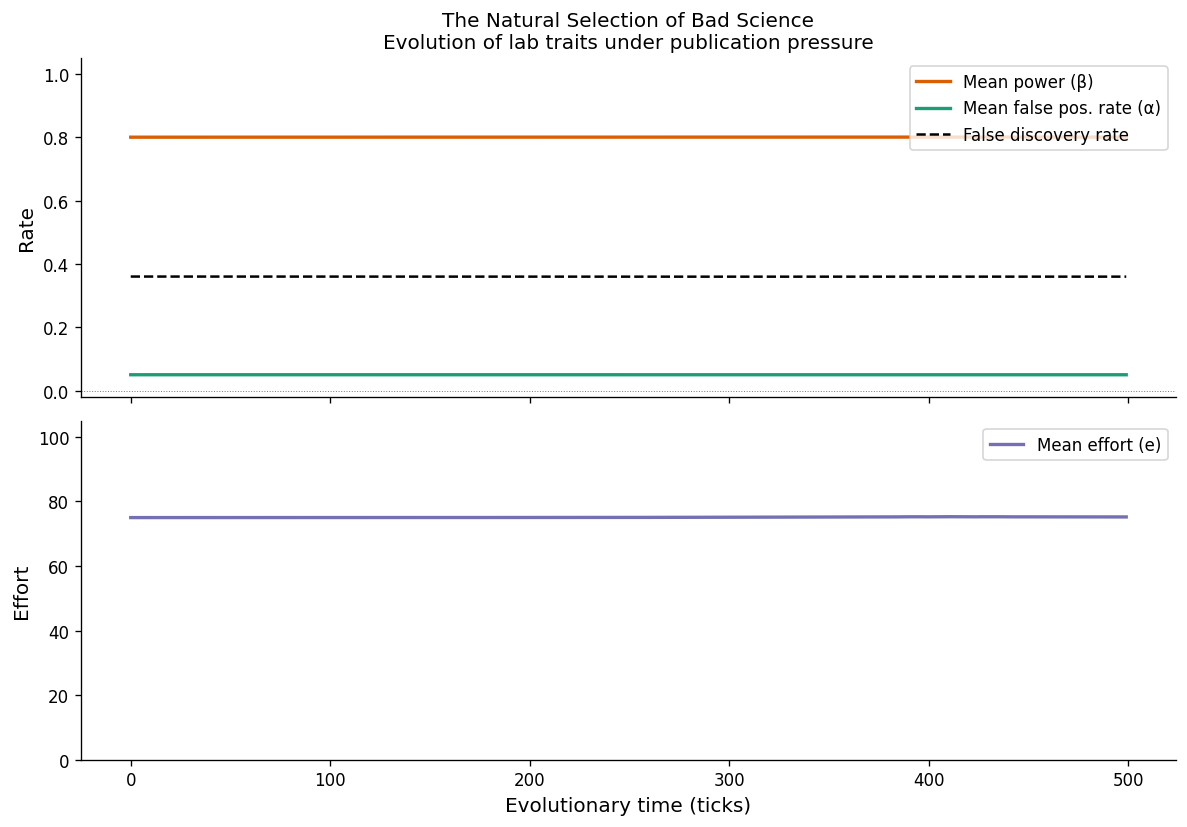

Final mean power:            0.800
Final mean false pos. rate:  0.050
Final false discovery rate:  0.360
Final mean effort:           75.20


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ticks = range(n_ticks)

# ── Top panel: Power and false positive rate ──────────────────────────────
ax = axes[0]
ax.plot(ticks, history["mean_power"], color="#d95f02", linewidth=2, label="Mean power (β)")
ax.plot(ticks, history["mean_fpr"],   color="#1b9e77", linewidth=2, label="Mean false pos. rate (α)")
ax.plot(ticks, history["fdr"],        color="black",   linewidth=1.5,
        linestyle="--", label="False discovery rate")
ax.set_ylabel("Rate", fontsize=12)
ax.set_title("The Natural Selection of Bad Science\nEvolution of lab traits under publication pressure",
             fontsize=12)
ax.legend(fontsize=10, loc="upper right")
ax.axhline(0.0, color="gray", linewidth=0.6, linestyle=":")
ax.set_ylim(-0.02, 1.05)

# ── Bottom panel: Effort ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(ticks, history["mean_effort"], color="#7570b3", linewidth=2, label="Mean effort (e)")
ax.set_xlabel("Evolutionary time (ticks)", fontsize=12)
ax.set_ylabel("Effort", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"Final mean power:            {history['mean_power'][-1]:.3f}")
print(f"Final mean false pos. rate:  {history['mean_fpr'][-1]:.3f}")
print(f"Final false discovery rate:  {history['fdr'][-1]:.3f}")
print(f"Final mean effort:           {history['mean_effort'][-1]:.2f}")

## Visualization 2 — The Role of Negative Result Incentives

What if we rewarded publishing negative results?  
Compare the evolutionary outcome under different `payoff_neg_result` and `prob_publish_neg_result` values.


  Done: No negative publication (baseline)
  Done: Moderate neg. publication (p=0.5, v=0.5)
  Done: Full neg. publication (p=1, v=1)


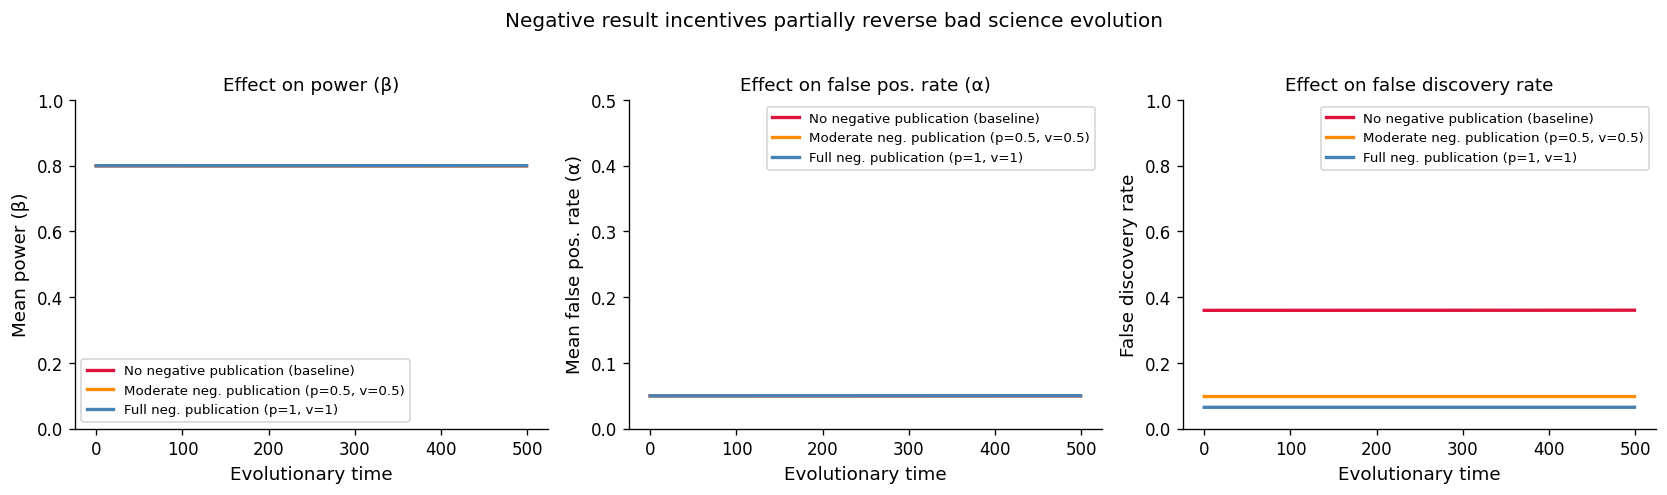

In [12]:
conditions = [
    {"prob_neg": 0.0, "payoff_neg": 0.0, "label": "No negative publication (baseline)", "color": "crimson"},
    {"prob_neg": 0.5, "payoff_neg": 0.5, "label": "Moderate neg. publication (p=0.5, v=0.5)", "color": "darkorange"},
    {"prob_neg": 1.0, "payoff_neg": 1.0, "label": "Full neg. publication (p=1, v=1)", "color": "steelblue"},
]

results = {}
for cond in conditions:
    np.random.seed(123)
    h = run_nsobs(
        num_labs=num_labs, power_init=power_init, effort_init=effort_init,
        base_rate=base_rate,
        prob_publish_neg_result=cond["prob_neg"],
        payoff_neg_result=cond["payoff_neg"],
        mutation_rate_power=mutation_rate_power, mutation_sd_power=mutation_sd_power,
        mutation_rate_effort=mutation_rate_effort, mutation_sd_effort=mutation_sd_effort,
        n_ticks=n_ticks
    )
    results[cond["label"]] = (h, cond["color"])
    print(f"  Done: {cond['label']}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
metrics   = [("mean_power", "Mean power (β)", (0, 1.0)),
             ("mean_fpr",   "Mean false pos. rate (α)", (0, 0.5)),
             ("fdr",        "False discovery rate", (0, 1.0))]

for ax, (metric, ylabel, ylim) in zip(axes, metrics):
    for label, (h, color) in results.items():
        ax.plot(h[metric], color=color, linewidth=2, label=label)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel("Evolutionary time", fontsize=11)
    ax.set_ylim(*ylim)
    ax.legend(fontsize=8)

axes[0].set_title("Effect on power (β)", fontsize=11)
axes[1].set_title("Effect on false pos. rate (α)", fontsize=11)
axes[2].set_title("Effect on false discovery rate", fontsize=11)

plt.suptitle("Negative result incentives partially reverse bad science evolution",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## Visualization 3 — Effect of Base Rate

The **base rate** is how often tested hypotheses are actually true.  
In exploratory fields (psychology, nutrition), base rates may be very low.  
In mature fields with strong theory, base rates are higher.

Low base rate → most tested hypotheses are false → false positives dominate publications.


  Done: base rate = 0.05
  Done: base rate = 0.1
  Done: base rate = 0.25
  Done: base rate = 0.5


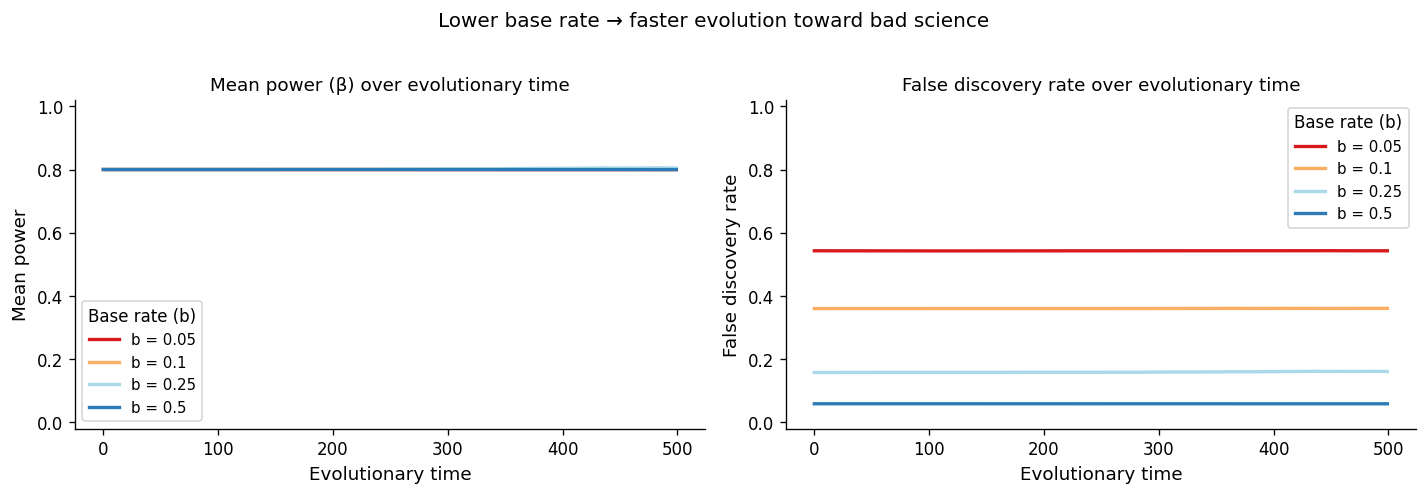

Lower base rates amplify the evolutionary pressure toward bad science.


In [13]:
base_rates = [0.05, 0.1, 0.25, 0.5]
colors_br  = ["#d7191c", "#fdae61", "#abd9e9", "#2c7bb6"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for br, col in zip(base_rates, colors_br):
    np.random.seed(7)
    h = run_nsobs(
        num_labs=num_labs, power_init=power_init, effort_init=effort_init,
        base_rate=br,
        prob_publish_neg_result=0.0, payoff_neg_result=0.0,
        mutation_rate_power=mutation_rate_power, mutation_sd_power=mutation_sd_power,
        mutation_rate_effort=mutation_rate_effort, mutation_sd_effort=mutation_sd_effort,
        n_ticks=n_ticks
    )
    axes[0].plot(h["mean_power"], color=col, linewidth=2,  label=f"b = {br}")
    axes[1].plot(h["fdr"],        color=col, linewidth=2,  label=f"b = {br}")
    print(f"  Done: base rate = {br}")

for ax, title, ylabel in zip(axes,
    ["Mean power (β) over evolutionary time", "False discovery rate over evolutionary time"],
    ["Mean power", "False discovery rate"]):
    ax.set_xlabel("Evolutionary time", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(title="Base rate (b)", fontsize=9)
    ax.set_ylim(-0.02, 1.02)

plt.suptitle("Lower base rate → faster evolution toward bad science", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("Lower base rates amplify the evolutionary pressure toward bad science.")


## 📝 Key Takeaways

| Concept | What the NSOBS model shows |
|---------|--------------------------|
| **Cultural evolution of science** | Lab practices are heritable and selectable — like biological traits |
| **Selection for quantity** | Publication pressure selects for high-throughput, low-rigor labs |
| **Power decreases over time** | Evolution reduces statistical power in the absence of countervailing incentives |
| **FPR increases over time** | The community drifts toward more false positives |
| **Negative result incentives help** | Rewarding null results partially reverses the evolutionary trend |
| **Low base rate amplifies the problem** | In speculative fields, bad science evolves faster |
| **No bad intentions required** | The outcome emerges from selection on publication count, not dishonesty |

---

### The mechanism in one sentence

**Labs that cut corners publish more papers, train more students, and win more grants —  
so their practices spread through the scientific community via cultural inheritance,  
even when everyone is acting rationally under the existing incentive structure.**

---

### What would fix it?

The model suggests several structural interventions:
1. **Reward negative results** — fund and publish null findings equally
2. **Pre-registration** — commit to study design before data collection (reduces selective reporting)
3. **Change hiring/tenure metrics** — evaluate quality, not just quantity
4. **Larger sample sizes** — mandate high power, penalize underpowered studies
5. **Open data** — allow reanalysis and reduce file-drawer bias

Each of these changes the *fitness landscape* so that rigor becomes selectively advantageous.

---

### Chapter 8 in one picture

```
Notebook 1: How beliefs SHOULD update (Bayesian ideal)
    ↓
Notebook 2: Why selection distorts what we see (Berkson's Paradox)
    ↓
Notebook 3: How suppressing negatives corrupts belief (Publication Bias)
    ↓
Notebook 4: Why bad practices EVOLVE and persist (Natural Selection of Bad Science)
```

The chapter builds a complete mechanistic theory of why science can systematically  
produce and perpetuate false knowledge — without invoking fraud or malice.

---
*Based on Smaldino (2023) Modeling Social Behavior, Chapter 8*  
*Original NetLogo model: `science_NSOBS.nlogo`*  
*Core reference: Smaldino PE & McElreath R (2016). Royal Society Open Science 3: 160384*
